In [1]:
import os

base = "/kaggle/input/datasets/anshuman9468"
print(os.listdir(base))

['duality-gtbit']


In [2]:
print(os.listdir("/kaggle/input/datasets/anshuman9468/duality-gtbit/Offroad_Segmentation_Training_Dataset/Offroad_Segmentation_Training_Dataset"))

['val', 'train']


In [3]:
data_dir = "/kaggle/input/datasets/anshuman9468/duality-gtbit/Offroad_Segmentation_Training_Dataset/Offroad_Segmentation_Training_Dataset/train"

print(os.listdir(data_dir))

['Segmentation', 'Color_Images']


In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!nvidia-smi

Thu Mar 19 07:20:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
print(os.listdir("/kaggle/input/duality-gtbit"))

print(os.listdir("/kaggle/input/duality-gtbit/Offroad_Segmentation_Training_Dataset"))

print(os.listdir("/kaggle/input/duality-gtbit/Offroad_Segmentation_Training_Dataset/Offroad_Segmentation_Training_Dataset"))

print(os.listdir("/kaggle/input/duality-gtbit/Offroad_Segmentation_Training_Dataset/Offroad_Segmentation_Training_Dataset/train"))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/duality-gtbit'

In [ ]:
"""
Segmentation Training Script
Converted from train_mask.ipynb
Trains a segmentation head on top of DINOv2 backbone
"""

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import cv2
import os
import torchvision
from tqdm import tqdm

# Set matplotlib to non-interactive backend
plt.switch_backend('Agg')


# ============================================================================
# Utility Functions
# ============================================================================

def save_image(img, filename):
    """Save an image tensor to file after denormalizing."""
    img = np.array(img)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.moveaxis(img, 0, -1)
    img = (img * std + mean) * 255
    cv2.imwrite(filename, img[:, :, ::-1])


# ============================================================================
# Mask Conversion
# ============================================================================

# Mapping from raw pixel values to new class IDs
value_map = {
    0: 0,        # background
    100: 1,      # Trees
    200: 2,      # Lush Bushes
    300: 3,      # Dry Grass
    500: 4,      # Dry Bushes
    550: 5,      # Ground Clutter
    700: 6,      # Logs
    800: 7,      # Rocks
    7100: 8,     # Landscape
    10000: 9     # Sky
}
n_classes = len(value_map)


def convert_mask(mask):
    """Convert raw mask values to class IDs."""
    arr = np.array(mask)
    new_arr = np.zeros_like(arr, dtype=np.uint8)
    for raw_value, new_value in value_map.items():
        new_arr[arr == raw_value] = new_value
    return Image.fromarray(new_arr)


# ============================================================================
# Dataset
# ============================================================================

class MaskDataset(Dataset):
    def __init__(self, data_dir, transform=None, mask_transform=None):
        self.image_dir = os.path.join(data_dir, 'Color_Images')
        self.masks_dir = os.path.join(data_dir, 'Segmentation')
        self.transform = transform
        self.mask_transform = mask_transform
        self.data_ids = os.listdir(self.image_dir)

    def __len__(self):
        return len(self.data_ids)

    def __getitem__(self, idx):
        data_id = self.data_ids[idx]
        img_path = os.path.join(self.image_dir, data_id)
        # Both color images and masks are .png files with same name
        mask_path = os.path.join(self.masks_dir, data_id)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        mask = convert_mask(mask)

        if self.transform:
            image = self.transform(image)
            mask = self.mask_transform(mask) * 255

        return image, mask


# ============================================================================
# Model: Segmentation Head (ConvNeXt-style)
# ============================================================================

class SegmentationHeadConvNeXt(nn.Module):
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H, self.W = tokenH, tokenW

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=7, padding=3),
            nn.GELU()
        )

        self.block = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=1),
            nn.GELU(),
        )

        self.classifier = nn.Conv2d(128, out_channels, 1)

    def forward(self, x):
        B, N, C = x.shape
        x = x.reshape(B, self.H, self.W, C).permute(0, 3, 1, 2)
        x = self.stem(x)
        x = self.block(x)
        return self.classifier(x)


# ============================================================================
# Metrics
# ============================================================================

def compute_iou(pred, target, num_classes=10, ignore_index=255):
    """Compute IoU for each class and return mean IoU."""
    pred = torch.argmax(pred, dim=1)
    pred, target = pred.view(-1), target.view(-1)

    iou_per_class = []
    for class_id in range(num_classes):
        if class_id == ignore_index:
            continue

        pred_inds = pred == class_id
        target_inds = target == class_id

        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            iou_per_class.append(float('nan'))
        else:
            iou_per_class.append((intersection / union).cpu().numpy())

    return np.nanmean(iou_per_class)


def compute_dice(pred, target, num_classes=10, smooth=1e-6):
    """Compute Dice coefficient (F1 Score) per class and return mean Dice Score."""
    pred = torch.argmax(pred, dim=1)
    pred, target = pred.view(-1), target.view(-1)

    dice_per_class = []
    for class_id in range(num_classes):
        pred_inds = pred == class_id
        target_inds = target == class_id

        intersection = (pred_inds & target_inds).sum().float()
        dice_score = (2. * intersection + smooth) / (pred_inds.sum().float() + target_inds.sum().float() + smooth)

        dice_per_class.append(dice_score.cpu().numpy())

    return np.mean(dice_per_class)


def compute_pixel_accuracy(pred, target):
    """Compute pixel accuracy."""
    pred_classes = torch.argmax(pred, dim=1)
    return (pred_classes == target).float().mean().cpu().numpy()


def evaluate_metrics(model, backbone, data_loader, device, num_classes=10, show_progress=True):
    """Evaluate all metrics on a dataset."""
    iou_scores = []
    dice_scores = []
    pixel_accuracies = []

    model.eval()
    loader = tqdm(data_loader, desc="Evaluating", leave=False, unit="batch") if show_progress else data_loader
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            output = backbone.forward_features(imgs)["x_norm_patchtokens"]
            logits = model(output.to(device))
            outputs = F.interpolate(logits, size=imgs.shape[2:], mode="bilinear", align_corners=False)

            labels = labels.squeeze(dim=1).long()

            iou = compute_iou(outputs, labels, num_classes=num_classes)
            dice = compute_dice(outputs, labels, num_classes=num_classes)
            pixel_acc = compute_pixel_accuracy(outputs, labels)

            iou_scores.append(iou)
            dice_scores.append(dice)
            pixel_accuracies.append(pixel_acc)

    model.train()
    return np.mean(iou_scores), np.mean(dice_scores), np.mean(pixel_accuracies)


# ============================================================================
# Plotting Functions
# ============================================================================

def save_training_plots(history, output_dir):
    """Save all training metric plots to files."""
    os.makedirs(output_dir, exist_ok=True)

    # Plot 1: Loss curves
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_pixel_acc'], label='train')
    plt.plot(history['val_pixel_acc'], label='val')
    plt.title('Pixel Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'training_curves.png'))
    plt.close()
    print(f"Saved training curves to '{output_dir}/training_curves.png'")

    # Plot 2: IoU curves
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_iou'], label='Train IoU')
    plt.title('Train IoU vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['val_iou'], label='Val IoU')
    plt.title('Validation IoU vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'iou_curves.png'))
    plt.close()
    print(f"Saved IoU curves to '{output_dir}/iou_curves.png'")

    # Plot 3: Dice curves
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_dice'], label='Train Dice')
    plt.title('Train Dice vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['val_dice'], label='Val Dice')
    plt.title('Validation Dice vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'dice_curves.png'))
    plt.close()
    print(f"Saved Dice curves to '{output_dir}/dice_curves.png'")

    # Plot 4: Combined metrics plot
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.title('Loss vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(history['train_iou'], label='train')
    plt.plot(history['val_iou'], label='val')
    plt.title('IoU vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.plot(history['train_dice'], label='train')
    plt.plot(history['val_dice'], label='val')
    plt.title('Dice Score vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(history['train_pixel_acc'], label='train')
    plt.plot(history['val_pixel_acc'], label='val')
    plt.title('Pixel Accuracy vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Pixel Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'all_metrics_curves.png'))
    plt.close()
    print(f"Saved combined metrics curves to '{output_dir}/all_metrics_curves.png'")


def save_history_to_file(history, output_dir):
    """Save training history to a text file."""
    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, 'evaluation_metrics.txt')

    with open(filepath, 'w') as f:
        f.write("TRAINING RESULTS\n")
        f.write("=" * 50 + "\n\n")

        f.write("Final Metrics:\n")
        f.write(f"  Final Train Loss:     {history['train_loss'][-1]:.4f}\n")
        f.write(f"  Final Val Loss:       {history['val_loss'][-1]:.4f}\n")
        f.write(f"  Final Train IoU:      {history['train_iou'][-1]:.4f}\n")
        f.write(f"  Final Val IoU:        {history['val_iou'][-1]:.4f}\n")
        f.write(f"  Final Train Dice:     {history['train_dice'][-1]:.4f}\n")
        f.write(f"  Final Val Dice:       {history['val_dice'][-1]:.4f}\n")
        f.write(f"  Final Train Accuracy: {history['train_pixel_acc'][-1]:.4f}\n")
        f.write(f"  Final Val Accuracy:   {history['val_pixel_acc'][-1]:.4f}\n")
        f.write("=" * 50 + "\n\n")

        f.write("Best Results:\n")
        f.write(f"  Best Val IoU:      {max(history['val_iou']):.4f} (Epoch {np.argmax(history['val_iou']) + 1})\n")
        f.write(f"  Best Val Dice:     {max(history['val_dice']):.4f} (Epoch {np.argmax(history['val_dice']) + 1})\n")
        f.write(f"  Best Val Accuracy: {max(history['val_pixel_acc']):.4f} (Epoch {np.argmax(history['val_pixel_acc']) + 1})\n")
        f.write(f"  Lowest Val Loss:   {min(history['val_loss']):.4f} (Epoch {np.argmin(history['val_loss']) + 1})\n")
        f.write("=" * 50 + "\n\n")

        f.write("Per-Epoch History:\n")
        f.write("-" * 100 + "\n")
        headers = ['Epoch', 'Train Loss', 'Val Loss', 'Train IoU', 'Val IoU',
                   'Train Dice', 'Val Dice', 'Train Acc', 'Val Acc']
        f.write("{:<8} {:<12} {:<12} {:<12} {:<12} {:<12} {:<12} {:<12} {:<12}\n".format(*headers))
        f.write("-" * 100 + "\n")

        n_epochs = len(history['train_loss'])
        for i in range(n_epochs):
            f.write("{:<8} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}\n".format(
                i + 1,
                history['train_loss'][i],
                history['val_loss'][i],
                history['train_iou'][i],
                history['val_iou'][i],
                history['train_dice'][i],
                history['val_dice'][i],
                history['train_pixel_acc'][i],
                history['val_pixel_acc'][i]
            ))

    print(f"Saved evaluation metrics to {filepath}")


# ============================================================================
# Main Training Function
# ============================================================================

def main():
    # Configuration
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Hyperparameters
    batch_size = 2
    w = int(((960 / 2) // 14) * 14)
    h = int(((540 / 2) // 14) * 14)
    lr = 1e-4
    n_epochs = 25

    # Output directory (relative to script location)
    script_dir = "/kaggle/working"
    output_dir = os.path.join(script_dir, 'train_stats')
    os.makedirs(output_dir, exist_ok=True)

    # Transforms
    transform = transforms.Compose([
        transforms.Resize((h, w)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    mask_transform = transforms.Compose([
        transforms.Resize((h, w)),
        transforms.ToTensor(),
    ])

    # Dataset paths (FIXED)
    data_dir = "/kaggle/input/datasets/anshuman9468/duality-gtbit/Offroad_Segmentation_Training_Dataset/Offroad_Segmentation_Training_Dataset/train"
    val_dir = "/kaggle/input/datasets/anshuman9468/duality-gtbit/Offroad_Segmentation_Training_Dataset/Offroad_Segmentation_Training_Dataset/val"
    # Create datasets
    trainset = MaskDataset(data_dir=data_dir, transform=transform, mask_transform=mask_transform)
    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)

    valset = MaskDataset(data_dir=val_dir, transform=transform, mask_transform=mask_transform)
    val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)

    print(f"Training samples: {len(trainset)}")
    print(f"Validation samples: {len(valset)}")

    # Load DINOv2 backbone
    print("Loading DINOv2 backbone...")
    BACKBONE_SIZE = "small"
    backbone_archs = {
        "small": "vits14",
        "base": "vitb14_reg",
        "large": "vitl14_reg",
        "giant": "vitg14_reg",
    }
    backbone_arch = backbone_archs[BACKBONE_SIZE]
    backbone_name = f"dinov2_{backbone_arch}"

    backbone_model = torch.hub.load(repo_or_dir="facebookresearch/dinov2", model=backbone_name)
    backbone_model.eval()
    backbone_model.to(device)
    print("Backbone loaded successfully!")

    # Get embedding dimension from backbone
    imgs, _ = next(iter(train_loader))
    imgs = imgs.to(device)
    with torch.no_grad():
        output = backbone_model.forward_features(imgs)["x_norm_patchtokens"]
    n_embedding = output.shape[2]
    print(f"Embedding dimension: {n_embedding}")
    print(f"Patch tokens shape: {output.shape}")

    # Create segmentation head
    classifier = SegmentationHeadConvNeXt(
        in_channels=n_embedding,
        out_channels=n_classes,
        tokenW=w // 14,
        tokenH=h // 14
    )
    classifier = classifier.to(device)

    # Loss and optimizer
    loss_fct = torch.nn.CrossEntropyLoss()
    optimizer = optim.SGD(classifier.parameters(), lr=lr, momentum=0.9)

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_iou': [],
        'val_iou': [],
        'train_dice': [],
        'val_dice': [],
        'train_pixel_acc': [],
        'val_pixel_acc': []
    }

    # Training loop
    print("\nStarting training...")
    print("=" * 80)

    epoch_pbar = tqdm(range(n_epochs), desc="Training", unit="epoch")
    for epoch in epoch_pbar:
        # Training phase
        classifier.train()
        train_losses = []

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} [Train]", 
                          leave=False, unit="batch")
        for imgs, labels in train_pbar:
            imgs, labels = imgs.to(device), labels.to(device)

            with torch.no_grad():
                output = backbone_model.forward_features(imgs)["x_norm_patchtokens"]

            logits = classifier(output.to(device))
            outputs = F.interpolate(logits, size=imgs.shape[2:], mode="bilinear", align_corners=False)

            labels = labels.squeeze(dim=1).long()

            loss = loss_fct(outputs, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_losses.append(loss.item())
            train_pbar.set_postfix(loss=f"{loss.item():.4f}")

        # Validation phase
        classifier.eval()
        val_losses = []

        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{n_epochs} [Val]", 
                        leave=False, unit="batch")
        with torch.no_grad():
            for imgs, labels in val_pbar:
                imgs, labels = imgs.to(device), labels.to(device)

                output = backbone_model.forward_features(imgs)["x_norm_patchtokens"]
                logits = classifier(output.to(device))
                outputs = F.interpolate(logits, size=imgs.shape[2:], mode="bilinear", align_corners=False)

                labels = labels.squeeze(dim=1).long()
                loss = loss_fct(outputs, labels)
                val_losses.append(loss.item())
                val_pbar.set_postfix(loss=f"{loss.item():.4f}")

        # Calculate metrics
        train_iou, train_dice, train_pixel_acc = evaluate_metrics(
            classifier, backbone_model, train_loader, device, num_classes=n_classes
        )
        val_iou, val_dice, val_pixel_acc = evaluate_metrics(
            classifier, backbone_model, val_loader, device, num_classes=n_classes
        )

        # Store history
        epoch_train_loss = np.mean(train_losses)
        epoch_val_loss = np.mean(val_losses)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_iou'].append(train_iou)
        history['val_iou'].append(val_iou)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        history['train_pixel_acc'].append(train_pixel_acc)
        history['val_pixel_acc'].append(val_pixel_acc)

        # Update epoch progress bar with metrics
        epoch_pbar.set_postfix(
            train_loss=f"{epoch_train_loss:.3f}",
            val_loss=f"{epoch_val_loss:.3f}",
            val_iou=f"{val_iou:.3f}",
            val_acc=f"{val_pixel_acc:.3f}"
        )

    # Save plots
    print("\nSaving training curves...")
    save_training_plots(history, output_dir)
    save_history_to_file(history, output_dir)

    # Save model (in scripts directory)
    model_path = os.path.join(script_dir, "segmentation_head.pth")
    torch.save(classifier.state_dict(), model_path)
    print(f"Saved model to '{model_path}'")

    # Final evaluation
    print("\nFinal evaluation results:")
    print(f"  Final Val Loss:     {history['val_loss'][-1]:.4f}")
    print(f"  Final Val IoU:      {history['val_iou'][-1]:.4f}")
    print(f"  Final Val Dice:     {history['val_dice'][-1]:.4f}")
    print(f"  Final Val Accuracy: {history['val_pixel_acc'][-1]:.4f}")

    print("\nTraining complete!")


if __name__ == "__main__":
    main()



Using device: cuda
Training samples: 2857
Validation samples: 317
Loading DINOv2 backbone...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 247MB/s] 


Backbone loaded successfully!
Embedding dimension: 384
Patch tokens shape: torch.Size([2, 646, 384])

Starting training...


Epoch 1/10 [Train]: 100%|██████████| 1429/1429 [03:17<00:00,  2.77batch/s, loss=0.7971]
                                                                                       
Epoch 1/10 [Val]:  99%|█████████▉| 158/159 [00:22<00:00,  7.29batch/s, loss=0.6743]
                                                                                   
Evaluating: 100%|█████████▉| 1428/1429 [02:36<00:00,  9.13batch/s]
                                                                  
Epoch 2/10 [Train]:  66%|██████▌   | 938/1429 [01:41<00:54,  9.00batch/s, loss=1.1617]

Evaluating: 100%|█████████▉| 1428/1429 [02:34<00:00,  9.28batch/s]
                                                                  
Epoch 4/10 [Train]:   8%|▊         | 109/1429 [00:11<02:23,  9.23batch/s, loss=0.9633]

Evaluating: 100%|█████████▉| 1428/1429 [02:34<00:00,  9.34batch/s]
                                                                  
Epoch 6/10 [Train]:  96%|█████████▌| 1369/1429 [02:28<00:06,  9.15batch/s, los

In [7]:
!ls /kaggle/working/

segmentation_head.pth  train_stats


In [13]:
!ls /kaggle/working/train_stats

all_metrics_curves.png	evaluation_metrics.txt	training_curves.png
dice_curves.png		iou_curves.png


In [14]:
!cat /kaggle/working/train_stats/evaluation_metrics.txt

TRAINING RESULTS

Final Metrics:
  Final Train Loss:     0.8194
  Final Val Loss:       0.8130
  Final Train IoU:      0.3203
  Final Val IoU:        0.3189
  Final Train Dice:     0.4405
  Final Val Dice:       0.4437
  Final Train Accuracy: 0.7013
  Final Val Accuracy:   0.7036

Best Results:
  Best Val IoU:      0.3189 (Epoch 10)
  Best Val Dice:     0.4437 (Epoch 10)
  Best Val Accuracy: 0.7036 (Epoch 10)
  Lowest Val Loss:   0.8130 (Epoch 10)

Per-Epoch History:
----------------------------------------------------------------------------------------------------
Epoch    Train Loss   Val Loss     Train IoU    Val IoU      Train Dice   Val Dice     Train Acc    Val Acc     
----------------------------------------------------------------------------------------------------
1        1.2421       1.0049       0.2249       0.2277       0.3171       0.3251       0.6500       0.6533      
2        0.9592       0.9195       0.2640       0.2636       0.3701       0.3737       0.6726       

In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
"""
Segmentation Training Script
Converted from train_mask.ipynb
Trains a segmentation head on top of DINOv2 backbone
"""

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import cv2
import os
import torchvision
from tqdm import tqdm

# Set matplotlib to non-interactive backend
plt.switch_backend('Agg')
torch.backends.cudnn.benchmark = True


# ============================================================================
# Utility Functions
# ============================================================================

def save_image(img, filename):
    """Save an image tensor to file after denormalizing."""
    img = np.array(img)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.moveaxis(img, 0, -1)
    img = (img * std + mean) * 255
    cv2.imwrite(filename, img[:, :, ::-1])


# ============================================================================
# Mask Conversion
# ============================================================================

# Mapping from raw pixel values to new class IDs
value_map = {
    0: 0,        # background
    100: 1,      # Trees
    200: 2,      # Lush Bushes
    300: 3,      # Dry Grass
    500: 4,      # Dry Bushes
    550: 5,      # Ground Clutter
    700: 6,      # Logs
    800: 7,      # Rocks
    7100: 8,     # Landscape
    10000: 9     # Sky
}
n_classes = len(value_map)


def convert_mask(mask):
    """Convert raw mask values to class IDs."""
    arr = np.array(mask)
    new_arr = np.zeros_like(arr, dtype=np.uint8)
    for raw_value, new_value in value_map.items():
        new_arr[arr == raw_value] = new_value
    return Image.fromarray(new_arr)


# ============================================================================
# Dataset
# ============================================================================

class MaskDataset(Dataset):
    def __init__(self, data_dir, transform=None, mask_transform=None):
        self.image_dir = os.path.join(data_dir, 'Color_Images')
        self.masks_dir = os.path.join(data_dir, 'Segmentation')
        self.transform = transform
        self.mask_transform = mask_transform
        self.data_ids = os.listdir(self.image_dir)

    def __len__(self):
        return len(self.data_ids)

    def __getitem__(self, idx):
        data_id = self.data_ids[idx]
        img_path = os.path.join(self.image_dir, data_id)
        # Both color images and masks are .png files with same name
        mask_path = os.path.join(self.masks_dir, data_id)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        mask = convert_mask(mask)

        if self.transform:
            image = self.transform(image)
            mask = self.mask_transform(mask) * 255

        return image, mask


# ============================================================================
# Model: Segmentation Head (ConvNeXt-style)
# ============================================================================

class SegmentationHeadConvNeXt(nn.Module):
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H, self.W = tokenH, tokenW

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=7, padding=3),
            nn.GELU()
        )

        self.block = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=1),
            nn.GELU(),
        )

        self.classifier = nn.Conv2d(128, out_channels, 1)

    def forward(self, x):
        B, N, C = x.shape
        x = x.reshape(B, self.H, self.W, C).permute(0, 3, 1, 2)
        x = self.stem(x)
        x = self.block(x)
        return self.classifier(x)


# ============================================================================
# Metrics
# ============================================================================

def compute_iou(pred, target, num_classes=10, ignore_index=255):
    """Compute IoU for each class and return mean IoU."""
    pred = torch.argmax(pred, dim=1)
    pred, target = pred.view(-1), target.view(-1)

    iou_per_class = []
    for class_id in range(num_classes):
        if class_id == ignore_index:
            continue

        pred_inds = pred == class_id
        target_inds = target == class_id

        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            iou_per_class.append(float('nan'))
        else:
            iou_per_class.append((intersection / union).cpu().numpy())

    return np.nanmean(iou_per_class)


def compute_dice(pred, target, num_classes=10, smooth=1e-6):
    """Compute Dice coefficient (F1 Score) per class and return mean Dice Score."""
    pred = torch.argmax(pred, dim=1)
    pred, target = pred.view(-1), target.view(-1)

    dice_per_class = []
    for class_id in range(num_classes):
        pred_inds = pred == class_id
        target_inds = target == class_id

        intersection = (pred_inds & target_inds).sum().float()
        dice_score = (2. * intersection + smooth) / (pred_inds.sum().float() + target_inds.sum().float() + smooth)

        dice_per_class.append(dice_score.cpu().numpy())

    return np.mean(dice_per_class)


def compute_pixel_accuracy(pred, target):
    """Compute pixel accuracy."""
    pred_classes = torch.argmax(pred, dim=1)
    return (pred_classes == target).float().mean().cpu().numpy()


def evaluate_metrics(model, backbone, data_loader, device, num_classes=10, show_progress=True):
    """Evaluate all metrics on a dataset."""
    iou_scores = []
    dice_scores = []
    pixel_accuracies = []

    model.eval()
    loader = tqdm(data_loader, desc="Evaluating", leave=False, unit="batch") if show_progress else data_loader
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            output = backbone.forward_features(imgs)["x_norm_patchtokens"]
            logits = model(output.to(device))
            outputs = F.interpolate(logits, size=imgs.shape[2:], mode="bilinear", align_corners=False)

            labels = labels.squeeze(dim=1).long()

            iou = compute_iou(outputs, labels, num_classes=num_classes)
            dice = compute_dice(outputs, labels, num_classes=num_classes)
            pixel_acc = compute_pixel_accuracy(outputs, labels)

            iou_scores.append(iou)
            dice_scores.append(dice)
            pixel_accuracies.append(pixel_acc)

    model.train()
    return np.mean(iou_scores), np.mean(dice_scores), np.mean(pixel_accuracies)


# ============================================================================
# Loss Functions
# ============================================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.softmax(preds, dim=1)
        targets_one_hot = torch.nn.functional.one_hot(targets, num_classes=n_classes).permute(0,3,1,2)

        intersection = (preds * targets_one_hot).sum(dim=(2,3))
        union = preds.sum(dim=(2,3)) + targets_one_hot.sum(dim=(2,3))

        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss()

def combined_loss(preds, targets):
    return ce_loss(preds, targets) + dice_loss(preds, targets)
# ============================================================================
# Plotting Functions
# ============================================================================

def save_training_plots(history, output_dir):
    """Save all training metric plots to files."""
    os.makedirs(output_dir, exist_ok=True)

    # Plot 1: Loss curves
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_pixel_acc'], label='train')
    plt.plot(history['val_pixel_acc'], label='val')
    plt.title('Pixel Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'training_curves.png'))
    plt.close()
    print(f"Saved training curves to '{output_dir}/training_curves.png'")

    # Plot 2: IoU curves
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_iou'], label='Train IoU')
    plt.title('Train IoU vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['val_iou'], label='Val IoU')
    plt.title('Validation IoU vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'iou_curves.png'))
    plt.close()
    print(f"Saved IoU curves to '{output_dir}/iou_curves.png'")

    # Plot 3: Dice curves
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_dice'], label='Train Dice')
    plt.title('Train Dice vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['val_dice'], label='Val Dice')
    plt.title('Validation Dice vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'dice_curves.png'))
    plt.close()
    print(f"Saved Dice curves to '{output_dir}/dice_curves.png'")

    # Plot 4: Combined metrics plot
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.title('Loss vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(history['train_iou'], label='train')
    plt.plot(history['val_iou'], label='val')
    plt.title('IoU vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.plot(history['train_dice'], label='train')
    plt.plot(history['val_dice'], label='val')
    plt.title('Dice Score vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(history['train_pixel_acc'], label='train')
    plt.plot(history['val_pixel_acc'], label='val')
    plt.title('Pixel Accuracy vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Pixel Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'all_metrics_curves.png'))
    plt.close()
    print(f"Saved combined metrics curves to '{output_dir}/all_metrics_curves.png'")


def save_history_to_file(history, output_dir):
    """Save training history to a text file."""
    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, 'evaluation_metrics.txt')

    with open(filepath, 'w') as f:
        f.write("TRAINING RESULTS\n")
        f.write("=" * 50 + "\n\n")

        f.write("Final Metrics:\n")
        f.write(f"  Final Train Loss:     {history['train_loss'][-1]:.4f}\n")
        f.write(f"  Final Val Loss:       {history['val_loss'][-1]:.4f}\n")
        f.write(f"  Final Train IoU:      {history['train_iou'][-1]:.4f}\n")
        f.write(f"  Final Val IoU:        {history['val_iou'][-1]:.4f}\n")
        f.write(f"  Final Train Dice:     {history['train_dice'][-1]:.4f}\n")
        f.write(f"  Final Val Dice:       {history['val_dice'][-1]:.4f}\n")
        f.write(f"  Final Train Accuracy: {history['train_pixel_acc'][-1]:.4f}\n")
        f.write(f"  Final Val Accuracy:   {history['val_pixel_acc'][-1]:.4f}\n")
        f.write("=" * 50 + "\n\n")

        f.write("Best Results:\n")
        f.write(f"  Best Val IoU:      {max(history['val_iou']):.4f} (Epoch {np.argmax(history['val_iou']) + 1})\n")
        f.write(f"  Best Val Dice:     {max(history['val_dice']):.4f} (Epoch {np.argmax(history['val_dice']) + 1})\n")
        f.write(f"  Best Val Accuracy: {max(history['val_pixel_acc']):.4f} (Epoch {np.argmax(history['val_pixel_acc']) + 1})\n")
        f.write(f"  Lowest Val Loss:   {min(history['val_loss']):.4f} (Epoch {np.argmin(history['val_loss']) + 1})\n")
        f.write("=" * 50 + "\n\n")

        f.write("Per-Epoch History:\n")
        f.write("-" * 100 + "\n")
        headers = ['Epoch', 'Train Loss', 'Val Loss', 'Train IoU', 'Val IoU',
                   'Train Dice', 'Val Dice', 'Train Acc', 'Val Acc']
        f.write("{:<8} {:<12} {:<12} {:<12} {:<12} {:<12} {:<12} {:<12} {:<12}\n".format(*headers))
        f.write("-" * 100 + "\n")

        n_epochs = len(history['train_loss'])
        for i in range(n_epochs):
            f.write("{:<8} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}\n".format(
                i + 1,
                history['train_loss'][i],
                history['val_loss'][i],
                history['train_iou'][i],
                history['val_iou'][i],
                history['train_dice'][i],
                history['val_dice'][i],
                history['train_pixel_acc'][i],
                history['val_pixel_acc'][i]
            ))

    print(f"Saved evaluation metrics to {filepath}")


# ============================================================================
# Main Training Function
# ============================================================================

def main():
    # Configuration
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Hyperparameters
    batch_size = 4
    w = int(((960 / 2) // 14) * 14)
    h = int(((540 / 2) // 14) * 14)
    lr = 1e-4
    n_epochs = 25

    # Output directory (relative to script location)
    script_dir = "/kaggle/working"
    output_dir = os.path.join(script_dir, 'train_stats')
    os.makedirs(output_dir, exist_ok=True)

    # Transforms
    transform = transforms.Compose([
        transforms.Resize((h, w)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                             std=[0.229, 0.224, 0.225])
    ])

    mask_transform = transforms.Compose([
        transforms.Resize((h, w)),
        transforms.ToTensor(),
    ])

    # Dataset paths (FIXED)
    data_dir = "/kaggle/input/datasets/anshuman9468/duality-gtbit/Offroad_Segmentation_Training_Dataset/Offroad_Segmentation_Training_Dataset/train"
    val_dir = "/kaggle/input/datasets/anshuman9468/duality-gtbit/Offroad_Segmentation_Training_Dataset/Offroad_Segmentation_Training_Dataset/val"
    # Create datasets
    trainset = MaskDataset(data_dir=data_dir, transform=transform, mask_transform=mask_transform)
    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)

    valset = MaskDataset(data_dir=val_dir, transform=transform, mask_transform=mask_transform)
    val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)

    print(f"Training samples: {len(trainset)}")
    print(f"Validation samples: {len(valset)}")

    # Load DINOv2 backbone
    print("Loading DINOv2 backbone...")
    BACKBONE_SIZE = "small"
    backbone_archs = {
        "small": "vits14",
        "base": "vitb14_reg",
        "large": "vitl14_reg",
        "giant": "vitg14_reg",
    }
    backbone_arch = backbone_archs[BACKBONE_SIZE]
    backbone_name = f"dinov2_{backbone_arch}"

    backbone_model = torch.hub.load(repo_or_dir="facebookresearch/dinov2", model=backbone_name)
    backbone_model.eval()
    backbone_model.to(device)
    print("Backbone loaded successfully!")

    # Get embedding dimension from backbone
    imgs, _ = next(iter(train_loader))
    imgs = imgs.to(device)
    with torch.no_grad():
        output = backbone_model.forward_features(imgs)["x_norm_patchtokens"]
    n_embedding = output.shape[2]
    print(f"Embedding dimension: {n_embedding}")
    print(f"Patch tokens shape: {output.shape}")

    # Create segmentation head
    classifier = SegmentationHeadConvNeXt(
        in_channels=n_embedding,
        out_channels=n_classes,
        tokenW=w // 14,
        tokenH=h // 14
    )
    classifier = classifier.to(device)

    # Loss and optimizer
    loss_fct = torch.nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_iou': [],
        'val_iou': [],
        'train_dice': [],
        'val_dice': [],
        'train_pixel_acc': [],
        'val_pixel_acc': []
    }

    # Training loop
    print("\nStarting training...")
    print("=" * 80)

    epoch_pbar = tqdm(range(n_epochs), desc="Training", unit="epoch")
    for epoch in epoch_pbar:
        # Training phase
        classifier.train()
        train_losses = []

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} [Train]", 
                          leave=False, unit="batch")
        for imgs, labels in train_pbar:
            imgs, labels = imgs.to(device), labels.to(device)

            with torch.no_grad():
                output = backbone_model.forward_features(imgs)["x_norm_patchtokens"].to(device)

            logits = classifier(output)
            outputs = F.interpolate(logits, size=imgs.shape[2:], mode="bilinear", align_corners=False)

            labels = labels.squeeze(dim=1).long()

            loss = combined_loss(outputs, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_losses.append(loss.item())
            train_pbar.set_postfix(loss=f"{loss.item():.4f}")

        # Validation phase
        classifier.eval()
        val_losses = []

        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{n_epochs} [Val]", 
                        leave=False, unit="batch")
        with torch.no_grad():
            for imgs, labels in val_pbar:
                imgs, labels = imgs.to(device), labels.to(device)

                output = backbone_model.forward_features(imgs)["x_norm_patchtokens"].to(device)
                logits = classifier(output)
                outputs = F.interpolate(logits, size=imgs.shape[2:], mode="bilinear", align_corners=False)

                labels = labels.squeeze(dim=1).long()
                loss = combined_loss(outputs, labels)
                val_losses.append(loss.item())
                val_pbar.set_postfix(loss=f"{loss.item():.4f}")

        # Calculate metrics
        train_iou, train_dice, train_pixel_acc = evaluate_metrics(
            classifier, backbone_model, train_loader, device, num_classes=n_classes
        )
        val_iou, val_dice, val_pixel_acc = evaluate_metrics(
            classifier, backbone_model, val_loader, device, num_classes=n_classes
        )

        # Store history
        epoch_train_loss = np.mean(train_losses)
        epoch_val_loss = np.mean(val_losses)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_iou'].append(train_iou)
        history['val_iou'].append(val_iou)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        history['train_pixel_acc'].append(train_pixel_acc)
        history['val_pixel_acc'].append(val_pixel_acc)

        # Update epoch progress bar with metrics
        epoch_pbar.set_postfix(
            train_loss=f"{epoch_train_loss:.3f}",
            val_loss=f"{epoch_val_loss:.3f}",
            val_iou=f"{val_iou:.3f}",
            val_acc=f"{val_pixel_acc:.3f}"
        )

        scheduler.step()

    # Save plots
    print("\nSaving training curves...")
    save_training_plots(history, output_dir)
    save_history_to_file(history, output_dir)

    # Save model (in scripts directory)
    model_path = os.path.join(script_dir, "segmentation_head.pth")
    torch.save(classifier.state_dict(), model_path)
    print(f"Saved model to '{model_path}'")

    # Final evaluation
    print("\nFinal evaluation results:")
    print(f"  Final Val Loss:     {history['val_loss'][-1]:.4f}")
    print(f"  Final Val IoU:      {history['val_iou'][-1]:.4f}")
    print(f"  Final Val Dice:     {history['val_dice'][-1]:.4f}")
    print(f"  Final Val Accuracy: {history['val_pixel_acc'][-1]:.4f}")

    print("\nTraining complete!")


if __name__ == "__main__":
    main()



Using device: cuda
Training samples: 2857
Validation samples: 317
Loading DINOv2 backbone...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:01<00:00, 45.1MB/s]


Backbone loaded successfully!
Embedding dimension: 384
Patch tokens shape: torch.Size([4, 646, 384])

Starting training...


Epoch 1/25 [Train]: 100%|██████████| 715/715 [03:57<00:00,  1.67batch/s, loss=1.8672]
                                                                                     
Epoch 1/25 [Val]: 100%|██████████| 80/80 [00:28<00:00,  3.34batch/s, loss=1.5506]
                                                                                 
Evaluating: 100%|█████████▉| 714/715 [02:38<00:00,  4.54batch/s]
                                                                
Epoch 2/25 [Train]: 100%|█████████▉| 714/715 [02:37<00:00,  4.38batch/s, loss=1.6714]
                                                                                     
Epoch 2/25 [Val]:  99%|█████████▉| 79/80 [00:18<00:00,  4.21batch/s, loss=1.5584]
                                                                                 
Evaluating: 100%|█████████▉| 714/715 [02:36<00:00,  4.61batch/s]
                                                                
Evaluating: 100%|█████████▉| 714/715 [02:36<00:00,  4.22batch/s]
   

In [5]:
!cat /kaggle/working/train_stats/evaluation_metrics.txt

TRAINING RESULTS

Final Metrics:
  Final Train Loss:     1.6404
  Final Val Loss:       1.6526
  Final Train IoU:      0.3064
  Final Val IoU:        0.3018
  Final Train Dice:     0.4147
  Final Val Dice:       0.4123
  Final Train Accuracy: 0.6696
  Final Val Accuracy:   0.6673

Best Results:
  Best Val IoU:      0.3018 (Epoch 25)
  Best Val Dice:     0.4123 (Epoch 25)
  Best Val Accuracy: 0.6681 (Epoch 21)
  Lowest Val Loss:   1.6511 (Epoch 23)

Per-Epoch History:
----------------------------------------------------------------------------------------------------
Epoch    Train Loss   Val Loss     Train IoU    Val IoU      Train Dice   Val Dice     Train Acc    Val Acc     
----------------------------------------------------------------------------------------------------
1        1.9618       1.8765       0.2312       0.2314       0.3195       0.3239       0.6216       0.6218      
2        1.8444       1.7986       0.2506       0.2482       0.3469       0.3470       0.6333       

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/kaggle/working/train_stats/all_metrics_curves.png")
plt.imshow(img)
plt.axis('off')
plt.show()

In [15]:
plt.show()

In [18]:
!ls /kaggle/working/train_stats

all_metrics_curves.png	evaluation_metrics.txt	training_curves.png
dice_curves.png		iou_curves.png


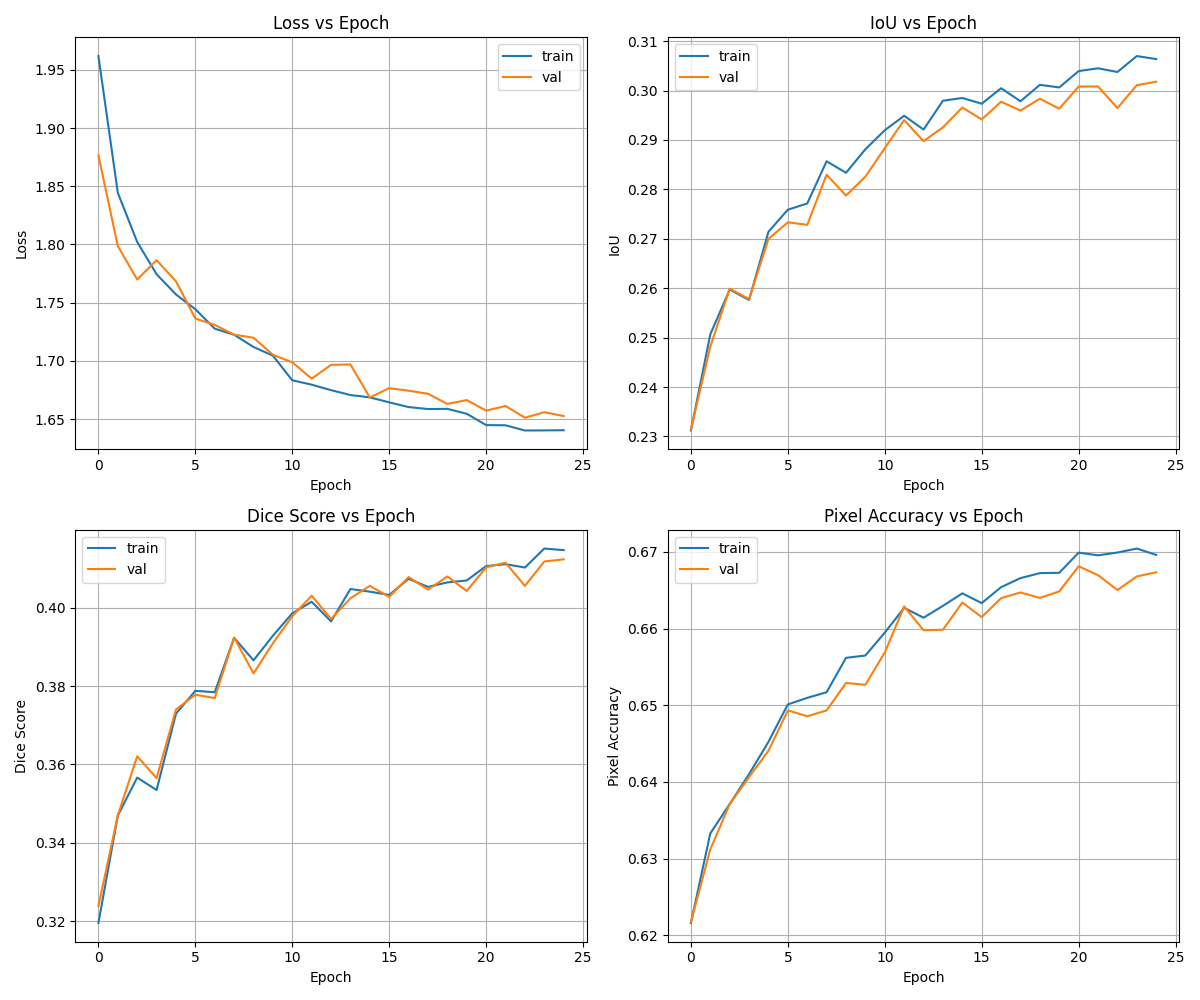

In [19]:
from IPython.display import Image, display

display(Image('/kaggle/working/train_stats/all_metrics_curves.png'))

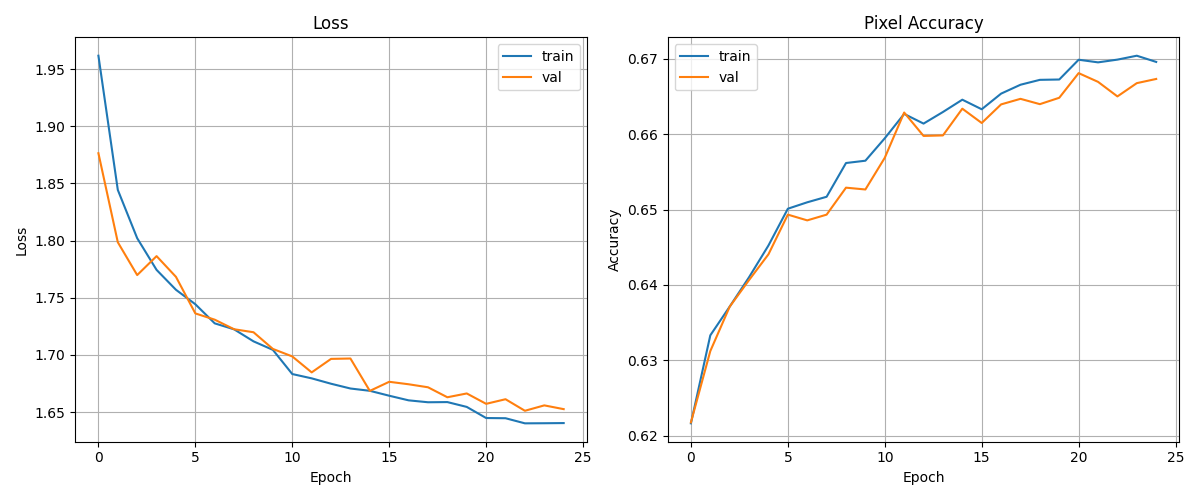

In [20]:
from IPython.display import Image, display

display(Image('/kaggle/working/train_stats/training_curves.png'))

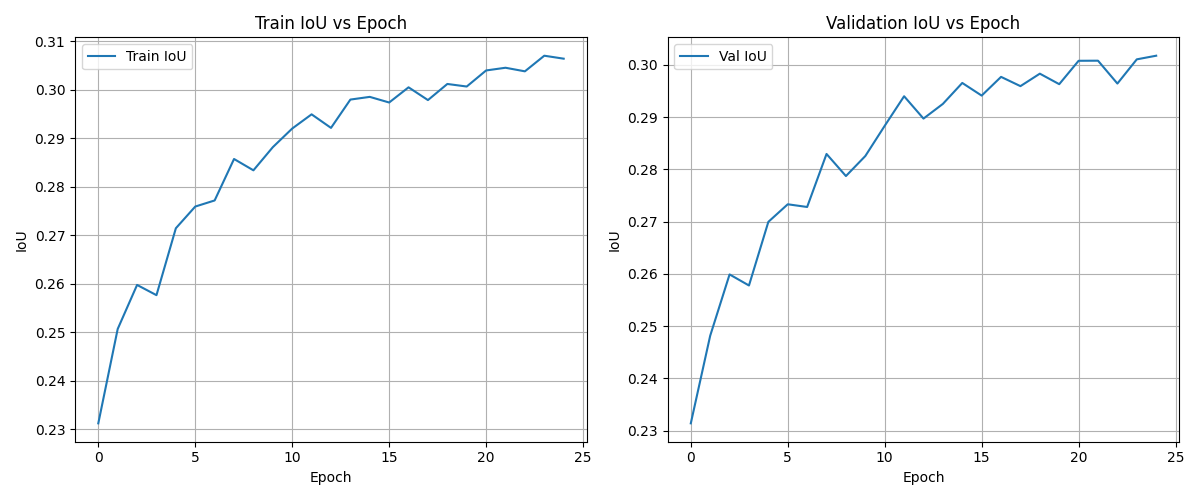

In [21]:
from IPython.display import Image, display

display(Image('/kaggle/working/train_stats/iou_curves.png'))

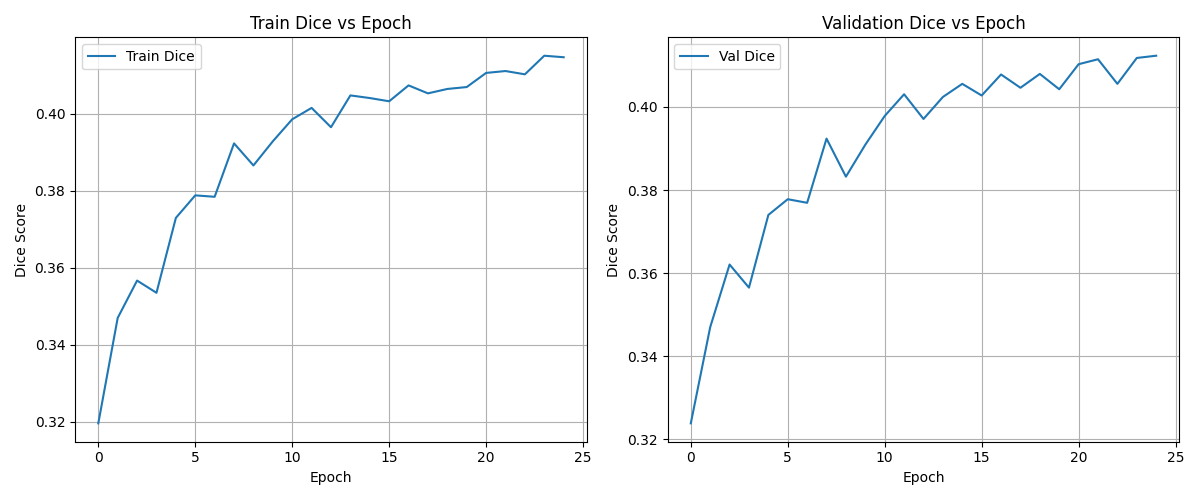

In [22]:
from IPython.display import Image, display

display(Image('/kaggle/working/train_stats/dice_curves.png'))

In [ ]:
"""
Segmentation Training Script - UPDATED
Trains a segmentation head on top of DINOv2 backbone
Key improvements:
  1. Partial backbone fine-tuning (last 2 blocks + norm)
  2. FPN-style decoder with progressive upsampling
  3. Synchronized augmentation via albumentations
  4. Class-weighted CE loss for imbalance
  5. Cosine annealing LR scheduler
  6. 50 epochs training
  7. Dual optimizer (head LR >> backbone LR)
"""

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import cv2
import os
import torchvision
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Set matplotlib to non-interactive backend
plt.switch_backend('Agg')
torch.backends.cudnn.benchmark = True


# ============================================================================
# Utility Functions
# ============================================================================

def save_image(img, filename):
    """Save an image tensor to file after denormalizing."""
    img = np.array(img)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = np.moveaxis(img, 0, -1)
    img  = (img * std + mean) * 255
    cv2.imwrite(filename, img[:, :, ::-1])


# ============================================================================
# Mask Conversion
# ============================================================================

value_map = {
    0:     0,   # background
    100:   1,   # Trees
    200:   2,   # Lush Bushes
    300:   3,   # Dry Grass
    500:   4,   # Dry Bushes
    550:   5,   # Ground Clutter
    700:   6,   # Logs
    800:   7,   # Rocks
    7100:  8,   # Landscape
    10000: 9    # Sky
}
n_classes = len(value_map)

# Class names for reference
CLASS_NAMES = [
    "Background", "Trees", "Lush Bushes", "Dry Grass",
    "Dry Bushes", "Ground Clutter", "Logs", "Rocks", "Landscape", "Sky"
]

def convert_mask(mask):
    """Convert raw mask values to class IDs."""
    arr     = np.array(mask)
    new_arr = np.zeros_like(arr, dtype=np.uint8)
    for raw_value, new_value in value_map.items():
        new_arr[arr == raw_value] = new_value
    return new_arr  # Return numpy array (needed for albumentations)


# ============================================================================
# Dataset  — uses albumentations for SYNCHRONIZED augmentation
# ============================================================================

class MaskDataset(Dataset):
    def __init__(self, data_dir, transform=None, is_train=True):
        self.image_dir  = os.path.join(data_dir, 'Color_Images')
        self.masks_dir  = os.path.join(data_dir, 'Segmentation')
        self.transform  = transform
        self.is_train   = is_train
        self.data_ids   = os.listdir(self.image_dir)

    def __len__(self):
        return len(self.data_ids)

    def __getitem__(self, idx):
        data_id  = self.data_ids[idx]
        img_path = os.path.join(self.image_dir, data_id)
        msk_path = os.path.join(self.masks_dir, data_id)

        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(msk_path))
        mask  = convert_mask(mask)   # uint8 class IDs

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]   # float32 tensor C×H×W
            mask  = augmented["mask"]    # long tensor H×W

        return image, mask.long()


# ============================================================================
# Albumentations Transforms  (image + mask stay in sync automatically)
# ============================================================================

def build_transforms(h, w, is_train=True):
    norm = A.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])

    if is_train:
        return A.Compose([
            A.Resize(h, w),
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2,
                               rotate_limit=15, border_mode=cv2.BORDER_REFLECT, p=0.5),
            A.ColorJitter(brightness=0.3, contrast=0.3,
                          saturation=0.2, hue=0.1, p=0.5),
            A.GaussianBlur(blur_limit=(3, 7), p=0.2),
            A.GridDistortion(p=0.2),
            norm,
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(h, w),
            norm,
            ToTensorV2(),
        ])


# ============================================================================
# Model: FPN-style Segmentation Head with Progressive Upsampling
# ============================================================================

class SegmentationHeadFPN(nn.Module):
    """
    Replaces the original single-block ConvNeXt head.
    Input  : (B, N, C)  patch tokens from DINOv2
    Output : (B, n_classes, tokenH*8, tokenW*8)  — upsampled ×8
    The final bilinear resize to full image resolution is done in the train loop.
    """
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H = tokenH
        self.W = tokenW

        # Project from DINOv2 embedding dim to 256
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 256, kernel_size=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            # Extra spatial mixing at patch scale
            nn.Conv2d(256, 256, kernel_size=3, padding=1, groups=32),
            nn.BatchNorm2d(256),
            nn.GELU(),
        )

        # Progressive decoder: ×2 → ×2 → ×2  (total ×8 upsample)
        self.up1 = self._up_block(256, 128)
        self.up2 = self._up_block(128, 64)
        self.up3 = self._up_block(64,  32)

        self.classifier = nn.Conv2d(32, out_channels, kernel_size=1)

        self._init_weights()

    @staticmethod
    def _up_block(in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B, N, C = x.shape
        x = x.reshape(B, self.H, self.W, C).permute(0, 3, 1, 2)  # B C H W
        x = self.stem(x)
        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        return self.classifier(x)


# ============================================================================
# Backbone Fine-tuning Helper
# ============================================================================

def prepare_backbone_for_finetuning(backbone):
    """
    Freeze all backbone parameters, then unfreeze the last 2 transformer
    blocks and the final LayerNorm so they can adapt to offroad domain.
    """
    # Step 1: freeze everything
    for param in backbone.parameters():
        param.requires_grad = False

    # Step 2: selectively unfreeze last 2 blocks + norm head
    unfreeze_keywords = ["blocks.10", "blocks.11", "norm"]
    unfrozen = 0
    for name, param in backbone.named_parameters():
        if any(kw in name for kw in unfreeze_keywords):
            param.requires_grad = True
            unfrozen += 1

    total = sum(p.numel() for p in backbone.parameters())
    trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
    print(f"Backbone: {trainable:,} / {total:,} params unfrozen "
          f"({100*trainable/total:.1f}%)")
    return backbone


# ============================================================================
# Metrics
# ============================================================================

def compute_iou(pred, target, num_classes=10):
    pred   = torch.argmax(pred, dim=1).view(-1)
    target = target.view(-1)

    iou_list = []
    for cls in range(num_classes):
        p = pred == cls
        t = target == cls
        inter = (p & t).sum().float()
        union = (p | t).sum().float()
        if union == 0:
            iou_list.append(float('nan'))
        else:
            iou_list.append((inter / union).item())
    return float(np.nanmean(iou_list))


def compute_dice(pred, target, num_classes=10, smooth=1e-6):
    pred   = torch.argmax(pred, dim=1).view(-1)
    target = target.view(-1)

    dice_list = []
    for cls in range(num_classes):
        p = pred == cls
        t = target == cls
        inter = (p & t).sum().float()
        score = (2. * inter + smooth) / (p.sum().float() + t.sum().float() + smooth)
        dice_list.append(score.item())
    return float(np.mean(dice_list))


def compute_pixel_accuracy(pred, target):
    pred_cls = torch.argmax(pred, dim=1)
    return (pred_cls == target).float().mean().item()


def evaluate_metrics(model, backbone, loader, device, num_classes=10):
    model.eval()
    iou_scores, dice_scores, acc_scores = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            feats   = backbone.forward_features(imgs)["x_norm_patchtokens"]
            logits  = model(feats)
            outputs = F.interpolate(logits, size=imgs.shape[2:],
                                    mode="bilinear", align_corners=False)

            iou_scores.append(compute_iou(outputs, labels, num_classes))
            dice_scores.append(compute_dice(outputs, labels, num_classes))
            acc_scores.append(compute_pixel_accuracy(outputs, labels))

    model.train()
    return np.mean(iou_scores), np.mean(dice_scores), np.mean(acc_scores)


# ============================================================================
# Loss Functions
# ============================================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds_soft = torch.softmax(preds, dim=1)
        targets_oh = F.one_hot(targets, num_classes=n_classes).permute(0, 3, 1, 2).float()
        inter = (preds_soft * targets_oh).sum(dim=(2, 3))
        union = preds_soft.sum(dim=(2, 3)) + targets_oh.sum(dim=(2, 3))
        dice  = (2. * inter + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


def build_loss(device):
    """
    Class-weighted CE + Dice.
    Weights downweight dominant classes (background, sky) and upweight
    rare but important classes (logs, rocks, ground clutter).
    Adjust these based on your actual class frequencies.
    """
    class_weights = torch.tensor([
        0.5,   # 0 background
        1.5,   # 1 Trees
        1.8,   # 2 Lush Bushes
        2.0,   # 3 Dry Grass
        2.0,   # 4 Dry Bushes
        2.5,   # 5 Ground Clutter
        3.0,   # 6 Logs
        3.0,   # 7 Rocks
        1.5,   # 8 Landscape
        0.8,   # 9 Sky
    ]).to(device)

    ce   = nn.CrossEntropyLoss(weight=class_weights)
    dice = DiceLoss()

    def combined(preds, targets):
        return ce(preds, targets) + dice(preds, targets)

    return combined


# ============================================================================
# Plotting & Logging
# ============================================================================

def save_training_plots(history, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    pairs = [
        ('train_loss',      'val_loss',      'Loss',           'Loss'),
        ('train_iou',       'val_iou',       'IoU',            'IoU'),
        ('train_dice',      'val_dice',      'Dice Score',     'Dice'),
        ('train_pixel_acc', 'val_pixel_acc', 'Pixel Accuracy', 'Accuracy'),
    ]
    for ax, (tr_key, va_key, title, ylabel) in zip(axes.flat, pairs):
        ax.plot(history[tr_key], label='train')
        ax.plot(history[va_key], label='val')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    path = os.path.join(output_dir, 'all_metrics_curves.png')
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Saved combined metrics plot → {path}")


def save_history_to_file(history, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, 'evaluation_metrics.txt')

    with open(path, 'w') as f:
        f.write("TRAINING RESULTS\n" + "=" * 60 + "\n\n")
        f.write("Final Metrics:\n")
        for key in history:
            f.write(f"  {key}: {history[key][-1]:.4f}\n")
        f.write("\nBest Results:\n")
        f.write(f"  Best Val IoU:      {max(history['val_iou']):.4f}  "
                f"(Epoch {np.argmax(history['val_iou'])+1})\n")
        f.write(f"  Best Val Dice:     {max(history['val_dice']):.4f}  "
                f"(Epoch {np.argmax(history['val_dice'])+1})\n")
        f.write(f"  Best Val Accuracy: {max(history['val_pixel_acc']):.4f}  "
                f"(Epoch {np.argmax(history['val_pixel_acc'])+1})\n")
        f.write(f"  Lowest Val Loss:   {min(history['val_loss']):.4f}  "
                f"(Epoch {np.argmin(history['val_loss'])+1})\n")

        f.write("\nPer-Epoch History:\n" + "-" * 110 + "\n")
        header = ['Epoch','Tr Loss','Va Loss','Tr IoU','Va IoU',
                  'Tr Dice','Va Dice','Tr Acc','Va Acc']
        f.write("{:<7} {:<10} {:<10} {:<9} {:<9} {:<9} {:<9} {:<9} {:<9}\n"
                .format(*header))
        f.write("-" * 110 + "\n")
        for i in range(len(history['train_loss'])):
            f.write("{:<7} {:<10.4f} {:<10.4f} {:<9.4f} {:<9.4f} "
                    "{:<9.4f} {:<9.4f} {:<9.4f} {:<9.4f}\n".format(
                        i+1,
                        history['train_loss'][i],  history['val_loss'][i],
                        history['train_iou'][i],   history['val_iou'][i],
                        history['train_dice'][i],  history['val_dice'][i],
                        history['train_pixel_acc'][i], history['val_pixel_acc'][i],
                    ))
    print(f"Saved metrics log → {path}")


# ============================================================================
# Main Training Function
# ============================================================================

def main():
    # ── Config ───────────────────────────────────────────────────────────────
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    batch_size = 4
    w = int(((960 / 2) // 14) * 14)   # 476
    h = int(((540 / 2) // 14) * 14)   # 266
    n_epochs   = 50
    head_lr    = 1e-4
    backbone_lr = 1e-5   # 10× smaller for fine-tuning

    script_dir = "/kaggle/working"
    output_dir = os.path.join(script_dir, 'train_stats')
    os.makedirs(output_dir, exist_ok=True)

    # ── Transforms (synchronized via albumentations) ──────────────────────
    train_tf = build_transforms(h, w, is_train=True)
    val_tf   = build_transforms(h, w, is_train=False)

    # ── Datasets ──────────────────────────────────────────────────────────
    data_dir = ("/kaggle/input/datasets/anshuman9468/duality-gtbit/"
                "Offroad_Segmentation_Training_Dataset/"
                "Offroad_Segmentation_Training_Dataset/train")
    val_dir  = ("/kaggle/input/datasets/anshuman9468/duality-gtbit/"
                "Offroad_Segmentation_Training_Dataset/"
                "Offroad_Segmentation_Training_Dataset/val")

    trainset = MaskDataset(data_dir, transform=train_tf, is_train=True)
    valset   = MaskDataset(val_dir,  transform=val_tf,   is_train=False)

    train_loader = DataLoader(trainset, batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(valset,   batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)

    print(f"Training samples:   {len(trainset)}")
    print(f"Validation samples: {len(valset)}")

    # ── Backbone ──────────────────────────────────────────────────────────
    print("\nLoading DINOv2 backbone (dinov2_vits14)...")
    backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
    backbone = prepare_backbone_for_finetuning(backbone)
    backbone.to(device)
    backbone.train()   # keep in train mode so unfrozen BN/LN updates
    print("Backbone ready.")

    # ── Get embedding dim ─────────────────────────────────────────────────
    with torch.no_grad():
        sample_imgs, _ = next(iter(train_loader))
        feats = backbone.forward_features(sample_imgs.to(device))["x_norm_patchtokens"]
    n_emb = feats.shape[2]
    print(f"DINOv2 embedding dim: {n_emb}  |  patch grid: {h//14} × {w//14}")

    # ── Segmentation Head ─────────────────────────────────────────────────
    classifier = SegmentationHeadFPN(
        in_channels=n_emb,
        out_channels=n_classes,
        tokenW=w // 14,
        tokenH=h // 14,
    ).to(device)
    print(f"Segmentation head params: "
          f"{sum(p.numel() for p in classifier.parameters()):,}")

    # ── Loss ──────────────────────────────────────────────────────────────
    combined_loss = build_loss(device)

    # ── Dual optimizer (different LR for head vs backbone) ───────────────
    backbone_params = [p for p in backbone.parameters() if p.requires_grad]
    optimizer = optim.AdamW([
        {"params": classifier.parameters(), "lr": head_lr,    "weight_decay": 1e-4},
        {"params": backbone_params,          "lr": backbone_lr, "weight_decay": 1e-4},
    ])

    # Cosine annealing — smooth decay over full training
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-6
    )

    # ── History ───────────────────────────────────────────────────────────
    history = {k: [] for k in [
        'train_loss', 'val_loss',
        'train_iou',  'val_iou',
        'train_dice', 'val_dice',
        'train_pixel_acc', 'val_pixel_acc',
    ]}

    best_val_iou  = 0.0
    best_ckpt     = os.path.join(script_dir, "segmentation_head_best.pth")

    # ── Training Loop ─────────────────────────────────────────────────────
    print(f"\nStarting training for {n_epochs} epochs...")
    print("=" * 80)

    for epoch in range(n_epochs):
        # ── Train ──────────────────────────────────────────────────────
        classifier.train()
        backbone.train()
        train_losses = []

        pbar = tqdm(train_loader,
                    desc=f"Epoch {epoch+1:02d}/{n_epochs} [Train]",
                    leave=False, unit="batch")
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)

            # backbone forward (unfrozen layers get gradients)
            feats  = backbone.forward_features(imgs)["x_norm_patchtokens"]
            logits = classifier(feats)
            outputs = F.interpolate(logits, size=imgs.shape[2:],
                                    mode="bilinear", align_corners=False)

            loss = combined_loss(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(classifier.parameters()) + backbone_params, max_norm=1.0
            )
            optimizer.step()

            train_losses.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        # ── Validate ───────────────────────────────────────────────────
        classifier.eval()
        backbone.eval()
        val_losses = []

        with torch.no_grad():
            for imgs, labels in tqdm(val_loader,
                                     desc=f"Epoch {epoch+1:02d}/{n_epochs} [Val]",
                                     leave=False, unit="batch"):
                imgs, labels = imgs.to(device), labels.to(device)
                feats   = backbone.forward_features(imgs)["x_norm_patchtokens"]
                logits  = classifier(feats)
                outputs = F.interpolate(logits, size=imgs.shape[2:],
                                        mode="bilinear", align_corners=False)
                val_losses.append(combined_loss(outputs, labels).item())

        # ── Metrics ────────────────────────────────────────────────────
        tr_iou, tr_dice, tr_acc = evaluate_metrics(
            classifier, backbone, train_loader, device, n_classes)
        va_iou, va_dice, va_acc = evaluate_metrics(
            classifier, backbone, val_loader, device, n_classes)

        ep_tr_loss = float(np.mean(train_losses))
        ep_va_loss = float(np.mean(val_losses))

        history['train_loss'].append(ep_tr_loss)
        history['val_loss'].append(ep_va_loss)
        history['train_iou'].append(tr_iou)
        history['val_iou'].append(va_iou)
        history['train_dice'].append(tr_dice)
        history['val_dice'].append(va_dice)
        history['train_pixel_acc'].append(tr_acc)
        history['val_pixel_acc'].append(va_acc)

        scheduler.step()

        current_lr_head = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{n_epochs} | "
              f"Loss {ep_tr_loss:.4f}/{ep_va_loss:.4f} | "
              f"IoU {tr_iou:.4f}/{va_iou:.4f} | "
              f"Dice {tr_dice:.4f}/{va_dice:.4f} | "
              f"Acc {tr_acc:.4f}/{va_acc:.4f} | "
              f"LR {current_lr_head:.2e}")

        # Save best checkpoint
        if va_iou > best_val_iou:
            best_val_iou = va_iou
            torch.save({
                'epoch': epoch + 1,
                'classifier_state': classifier.state_dict(),
                'backbone_state':   backbone.state_dict(),
                'optimizer_state':  optimizer.state_dict(),
                'val_iou':          va_iou,
            }, best_ckpt)
            print(f"  ✓ New best val IoU: {best_val_iou:.4f} — checkpoint saved.")

    # ── Save final model & plots ──────────────────────────────────────────
    print("\nSaving final model & training curves...")
    torch.save(classifier.state_dict(),
               os.path.join(script_dir, "segmentation_head_final.pth"))
    save_training_plots(history, output_dir)
    save_history_to_file(history, output_dir)

    print("\n" + "=" * 60)
    print("FINAL RESULTS")
    print("=" * 60)
    print(f"  Best  Val IoU:      {best_val_iou:.4f}")
    print(f"  Final Val Loss:     {history['val_loss'][-1]:.4f}")
    print(f"  Final Val IoU:      {history['val_iou'][-1]:.4f}")
    print(f"  Final Val Dice:     {history['val_dice'][-1]:.4f}")
    print(f"  Final Val Accuracy: {history['val_pixel_acc'][-1]:.4f}")
    print("=" * 60)
    print("Training complete!")


if __name__ == "__main__":
    main()